In [8]:
import torch 
from torch.utils.data import DataLoader
from torchvision import datasets 
from torchvision.transforms import ToTensor 
import utils
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

In [9]:
# create Tensor
x = [[1,2,3],[4,5,6]]
x = torch.tensor(x)
print(type(x))
print(x)

<class 'torch.Tensor'>
tensor([[1, 2, 3],
        [4, 5, 6]])


In [10]:
# download data for practicing
train_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)
test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

In [ ]:
image, label = train_data[0]
print(type(image))
print(image.shape)
print(label)

<class 'torch.Tensor'>
torch.Size([1, 28, 28])
tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0.]]])
5


In [ ]:
# make data into several batches
train_loader = DataLoader(train_data,batch_size=32,shuffle=False)
test_loader = DataLoader(test_data,batch_size=32,shuffle=False)

# so that later we can use it in a way like
# for x,y in train_loader:
#   model(x)

Tensor dimension of a single batch
(batch_size x channels x height x width): [32, 1, 28, 28]


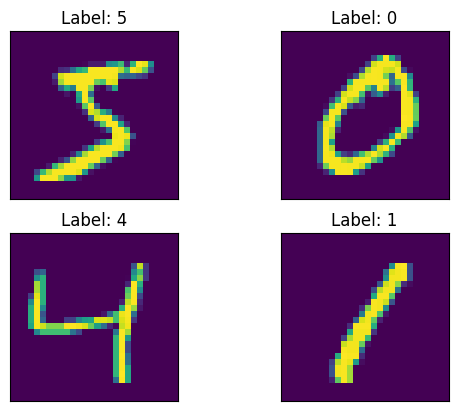

In [20]:
# have a look inside the data loader
def visualize_first_4(batch, labels):
    fig, axs = plt.subplots(2, 2)
    for i, j in product((0, 1), (0, 1)):
        axs[i, j].imshow(batch[2*i + j][0])
        axs[i, j].set_title(f"Label: {labels[2*i + j]}")
        axs[i, j].tick_params(left = False, right = False , labelleft = False ,
                labelbottom = False, bottom = False)
    plt.show()

for batch, labels in train_loader:
    print(
        """Tensor dimension of a single batch
(batch_size x channels x height x width):""", list(batch.shape))
    visualize_first_4(batch, labels)
    break

In [31]:
# ToTensor() can make image data into Tensor, so that PyTorch can calculate it
# PIL Image / Numpy Array -> torch.tensor
# pixel 0-255  -> 0~1
transform = ToTensor() 

image = np.array([
    [0,255],
    [128,64]
], dtype=np.uint8)
tensor = transform(image) # if data type is not uint8, it won't do normalization
print(image.dtype)
print(tensor)

image = np.array([
    [0,255],
    [128,64]
])
tensor = transform(image) # if data type is not uint8, it won't do normalization
print(image.dtype)
print(tensor)

uint8
tensor([[[0.0000, 1.0000],
         [0.5020, 0.2510]]])
int64
tensor([[[  0, 255],
         [128,  64]]])


In [ ]:
# write python class and understand inheritance

class Sweet():
    def __init__(self):
        self.taste = "sweet"
    def get_taste(self):
        return self.taste

class Sauer(Sweet):
    def __init__(self):
        super().__init__()
        self.aroma = "Sauer"
    
    def get_aroma(self):
        return self.aroma
    

pineapple = Sauer()
print(pineapple.get_aroma())

Sauer


In [25]:
class B:
    def __init__(self):
        print("B Constructor")

class A(B):
    def __init__(self):
        super().__init__()
        print("A Constructor")

a = A()

B Constructor
A Constructor


In [ ]:
# try out nn.linear()